In [1]:
import torch

### Import PDF Document

In [2]:
import os
import requests

#Get PDF document path
pdf_path="human-nutrition-text.pdf"

#Download PDF
if not os.path.exists(pdf_path):
    print(" File doesn't exist, downloading..")

    #Enter the URL of the pdf
    url="https://pressbooks.oer.hawaii.edu/humannutrition2/"

    #The local filename to save the download file
    filename= pdf_path

    #Send a GET Request to the URL
    reponse = requests.get(url)

    #Check if the request was succesful
    if response.status_code==200:
        with open(filename, "wb") as file:
            file.write(reponse.content)
        print(f"The file has been downloaded and saved as {filename}")
    else:
        print(f"Failed to download the file. Status code: {response.status_code}")
else:
    print(f"File {pdf_path} exists.")

File human-nutrition-text.pdf exists.


In [3]:
import fitz
from tqdm.auto import tqdm

def text_formatter(text:str) -> str:
    cleaned_text = text.replace("\n", " ").strip()
    return cleaned_text

def open_and_read_pdf(pdf_path:str) -> list[dict]:
    doc = fitz.open(pdf_path)
    pages_and_texts = []

    for page_number, page in tqdm(enumerate(doc)):
        text = page.get_text()
        text = text_formatter(text=text)
        pages_and_texts.append({"page_number" : page_number-41,
                                "page_char_count" : len(text),
                                "page_word_count" : len(text.split(" ")),
                                "page_sentence_count_raw" : len(text.split(". ")),
                                "page_token_count" : len(text) / 4,
                                "text" : text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

0it [00:00, ?it/s]

[{'page_number': -41,
  'page_char_count': 29,
  'page_word_count': 4,
  'page_sentence_count_raw': 1,
  'page_token_count': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_number': -40,
  'page_char_count': 0,
  'page_word_count': 1,
  'page_sentence_count_raw': 1,
  'page_token_count': 0.0,
  'text': ''}]

In [4]:
import random
random.sample(pages_and_texts, k= 3)

[{'page_number': 698,
  'page_char_count': 1071,
  'page_word_count': 214,
  'page_sentence_count_raw': 16,
  'page_token_count': 267.75,
  'text': 'Dietary Sources of Fluoride  Greater than 70 percent of a person’s fluoride comes from drinking  fluoridated water when they live in a community that fluoridates  the drinking water. Other beverages with a high amount of fluoride  include teas and grape juice. Solid foods do not contain a large  amount of fluoride. Fluoride content in foods depends on whether  it was grown in soils and water that contained fluoride or cooked  with fluoridated water. Canned meats and fish that contain bones  do contain some fluoride.  Table 11.11 Fluoride Content of Various Foods  Food  Serving Fluoride  (mg)  Percent Daily  Value*  Fruit Juice  3.5 fl  oz.  0.02-2.1  0.7-70  Crab, canned  3.5 oz.  0.21  7  Rice, cooked  3.5 oz.  0.04  1.3  Fish, cooked  3.5 oz.  0.02  0.7  Chicken  3.5 oz.  0.015  0.5  * Current AI used to determine  Percent Daily Value  M

In [5]:
import pandas as pd

df=pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-41,29,4,1,7.25,Human Nutrition: 2020 Edition
1,-40,0,1,1,0.00,
2,-39,320,54,1,80.00,Human Nutrition: 2020 Edition UNIVERSITY OF ...
3,-38,212,32,1,53.00,Human Nutrition: 2020 Edition by University of...
4,-37,797,145,2,199.25,Contents Preface University of Hawai‘i at Mā...


In [6]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00
std,348.86,560.38,95.76,6.19,140.10
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,762.00,134.00,4.00,190.50
50%,562.50,1231.50,214.50,10.00,307.88
75%,864.25,1603.50,271.00,14.00,400.88
max,1166.00,2308.00,429.00,32.00,577.00


### Further text processing (splitting pages into sentence)

In [7]:
from spacy.lang.en import English

nlp=English()

#Add a sentencizer pipeline
nlp.add_pipe("sentencizer")

#create document instance as an example
doc = nlp("This is a sentence. This another sentence. I like elephants.")
assert(len(list(doc.sents))) ==3

list(doc.sents)

[This is a sentence., This another sentence., I like elephants.]

In [8]:
from spacy.lang.en import English
from tqdm import tqdm

nlp = English()
nlp.add_pipe("sentencizer")

num_sentence_chunk_size = 10

def split_list(input_list, slice_size):
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

for item in tqdm(pages_and_texts):
    # Spacy sentence detection
    doc = nlp(item["text"])
    item["sentences"] = [str(s) for s in doc.sents]

    # Chunking
    item["sentence_chunks"] = split_list(item["sentences"], num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])


100%|█████████████████████████████████████████████████████████████████████████████| 1208/1208 [00:04<00:00, 247.62it/s]


In [9]:
print("Total chunks:", sum(item["num_chunks"] for item in pages_and_texts))


Total chunks: 1843


In [10]:
pages_and_texts[0]

{'page_number': -41,
 'page_char_count': 29,
 'page_word_count': 4,
 'page_sentence_count_raw': 1,
 'page_token_count': 7.25,
 'text': 'Human Nutrition: 2020 Edition',
 'sentences': ['Human Nutrition: 2020 Edition'],
 'sentence_chunks': [['Human Nutrition: 2020 Edition']],
 'num_chunks': 1}

In [11]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]
    item["page_sentence_count_spacy"] = len(item["sentences"])
     

100%|█████████████████████████████████████████████████████████████████████████████| 1208/1208 [00:04<00:00, 300.04it/s]


In [12]:
random.sample(pages_and_texts, k=1)

[{'page_number': 528,
  'page_char_count': 1305,
  'page_word_count': 246,
  'page_sentence_count_raw': 9,
  'page_token_count': 326.25,
  'text': 'The RDA for vitamin A is considered sufficient to support growth  and development, reproduction, vision, and immune system  function while maintaining adequate stores (good for four months)  in the liver.  Table 9.1 Dietary Reference Intakes for Vitamin A  Age Group  RDA Males and Females mcg RAE/ day  UL  Infants (0–6 months)  400*  600  Infants (7–12 months)  500*  600  Children (1–3 years)  300  600  Children (4–8 years)  400  900  Children (9–13 years)  600  1,700  Adolescents (14–18 years)  Males: 900  2,800  Adolescents (14–18 years)  Females: 700  2,800  Adults (> 19 years)  Males: 900  3,000  Adults (> 19 years)  Females: 700  3,000  *denotes Adequate  Intake  Source: Source: Dietary Supplement Fact Sheet: Vitamin A. National  Institutes  of  Health,  Office  of  Dietary  Supplements.  http://ods.od.nih.gov/factsheets/VitaminA-Quick

In [13]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,num_chunks,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00,1.53,10.32
std,348.86,560.38,95.76,6.19,140.10,0.64,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,4.00,190.50,1.00,5.00
50%,562.50,1231.50,214.50,10.00,307.88,1.00,10.00
75%,864.25,1603.50,271.00,14.00,400.88,2.00,15.00
max,1166.00,2308.00,429.00,32.00,577.00,3.00,28.00


### Chunking our sentence together

In [14]:
#define split size to turn groups of sentence into chunks 
num_sentence_chunk_size = 10

#create a function to split lists of texts recursively into chunk size

def split_list(input_list : list[str],
               slice_size : int=num_sentence_chunk_size) -> list[list[str]]:
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

test_list = list(range(25))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [15]:
#loop through pages and texts and split sentence into chunks
for items in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

100%|███████████████████████████████████████████████████████████████████████████| 1208/1208 [00:00<00:00, 75359.48it/s]


In [16]:
random.sample(pages_and_texts, k=1)

[{'page_number': 600,
  'page_char_count': 1499,
  'page_word_count': 240,
  'page_sentence_count_raw': 11,
  'page_token_count': 374.75,
  'text': 'Phytochemicals  UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  Phytochemicals are chemicals in plants that may provide some  health benefit. Carotenoids are one type of phytochemical.  Phytochemicals also include indoles, lignans, phytoestrogens,  stanols,  saponins,  terpenes,  flavonoids,  carotenoids,  anthocyanidins, phenolic acids, and many more. They are found not  only in fruits and vegetables, but also in grains, seeds, nuts, and  legumes.  Many phytochemicals act as antioxidants, but they have several  other functions, such as mimicking hormones, altering absorption  of cholesterol, inhibiting inflammatory responses, and blocking the  actions of certain enzymes.  Phytochemicals are present in small amounts in the food supply,  and although thousands have been and are currently

In [17]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,num_chunks,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00,1.53,10.32
std,348.86,560.38,95.76,6.19,140.10,0.64,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,4.00,190.50,1.00,5.00
50%,562.50,1231.50,214.50,10.00,307.88,1.00,10.00
75%,864.25,1603.50,271.00,14.00,400.88,2.00,15.00
max,1166.00,2308.00,429.00,32.00,577.00,3.00,28.00


### Splitting each chunk into its own items

In [18]:
import re

#Split each chunks into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    if "sentence_chunks" not in item:
        continue
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict={}
        chunk_dict["page_number"] = item["page_number"]

        #join the sentence together into a paragraph
        joined_sentence_chunk = "".join(sentence_chunk).replace("  "," ").strip()
        chunk_dict["sentence_chunk"] = joined_sentence_chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk)/4 #1 token = -4chars

        pages_and_chunks.append(chunk_dict)
len(pages_and_chunks)

100%|████████████████████████████████████████████████████████████████████████████| 1208/1208 [00:00<00:00, 9299.24it/s]


1843

In [19]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 772,
  'sentence_chunk': '4.\xa0Key Recommendations: Components of Healthy Living Patterns.Dietary Guidelines 2015-2020. https://health.gov/dietaryguidelines/2015/guidelines/ chapter-1/key-recommendations/. Published 2015. Accessed November 22, 2017. 772 | Understanding the Bigger Picture of Dietary Guidelines',
  'chunk_char_count': 282,
  'chunk_word_count': 26,
  'chunk_token_count': 70.5}]

In [20]:
df=pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,583.38,731.11,109.00,182.78
std,347.79,445.65,69.34,111.41
min,-41.00,12.00,3.00,3.00
25%,280.50,313.50,43.00,78.38
50%,586.00,745.00,111.00,186.25
75%,890.00,1112.00,168.00,278.00
max,1166.00,1824.00,290.00,456.00


In [21]:
df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
0,-41,Human Nutrition: 2020 Edition,29,4,7.25
1,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00
2,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50
3,-37,Contents Preface University of Hawai‘i at Māno...,765,113,191.25
4,-36,Lifestyles and Nutrition University of Hawai‘i...,940,141,235.00


Filter chunks of text for short chunks

In [22]:
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text : {row[1]["sentence_chunk"]}')

Chunk token count: 6.5 | Text : Fat-Soluble Vitamins | 539
Chunk token count: 5.5 | Text : 1050 | Comparing Diets
Chunk token count: 23.0 | Text : view it online here: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=301 The Atom | 471
Chunk token count: 16.25 | Text : Updated March 12, 2015.Accessed December 5, 2017. 882 | Childhood
Chunk token count: 28.5 | Text : The World Bank claims that a million deaths occur every year from anemia and that the majority of those Iron | 663


In [23]:
#Filter out dataframe for rows with under 30 tokens

pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -39,
  'sentence_chunk': 'Human Nutrition: 2020 Edition UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM ALAN TITCHENAL, SKYLAR HARA, NOEMI ARCEO CAACBAY, WILLIAM MEINKE-LAU, YA-YUN YANG, MARIE KAINOA FIALKOWSKI REVILLA, JENNIFER DRAPER, GEMADY LANGFELDER, CHERYL GIBBY, CHYNA NICOLE CHUN, AND ALLISON CALABRESE',
  'chunk_char_count': 308,
  'chunk_word_count': 42,
  'chunk_token_count': 77.0},
 {'page_number': -38,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and Human Nutrition Program is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.',
  'chunk_char_count': 210,
  'chunk_word_count': 30,
  'chunk_token_count': 52.5}]

In [24]:
random.sample(pages_and_chunks_over_min_token_len, k =1)

[{'page_number': 446,
  'sentence_chunk': 'Once the heart structure and function is compromised, the more susceptible a patient would be to suffer a second heart attack. 446 | Health Consequences of Alcohol Abuse',
  'chunk_char_count': 169,
  'chunk_word_count': 28,
  'chunk_token_count': 42.25}]

### Embedding our text chunks

In [25]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", device="cpu")

#Creat a list of sentences
sentences = ["The sentence Tranformer library provides an easy way to create embeddings.",
             "Sentences can be embedded ony by one or in a list.",
             "I like horse"]
    
#Sentences are embedded/encoded by calling model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

#See the embedding
for sentence, embedding in embeddings_dict.items():
    print(f"Sentences:{sentences}")
    print(f"Embedding : {embedding}")
    print("")

Sentences:['The sentence Tranformer library provides an easy way to create embeddings.', 'Sentences can be embedded ony by one or in a list.', 'I like horse']
Embedding : [-3.88789438e-02  2.93957405e-02 -1.89742520e-02  5.45278937e-02
 -2.46965475e-02 -5.69565361e-03  7.98191503e-03 -6.87656924e-02
  1.41744977e-02 -2.27454416e-02  3.59531157e-02  4.59596291e-02
 -3.38348374e-02  1.19769378e-02  5.14109768e-02 -5.52369878e-02
  5.38392067e-02  1.60356588e-03 -1.37175173e-02  7.11232889e-03
  4.49637696e-02  4.04905416e-02  2.39936635e-02  2.25788262e-02
 -3.59329674e-03 -3.08354739e-02  2.47938070e-03 -3.31778862e-02
  5.50235398e-02 -1.12248939e-02 -3.84661146e-02 -1.50205959e-02
  6.25272542e-02  3.73070012e-03  9.55762971e-07  1.23930965e-02
 -4.37590517e-02 -7.38405099e-04  4.08840505e-03  1.20603414e-02
  5.67637533e-02 -5.86028248e-02  1.08249197e-02  5.08761406e-02
 -2.68194340e-02 -1.04454122e-02  5.05793728e-02 -7.17288814e-03
  8.33992735e-02  5.35265096e-02 -1.92068797e-02 

In [26]:
embeddings[0].shape

(768,)

In [27]:
%%time

text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]
text_chunks[419]

CPU times: total: 0 ns
Wall time: 1.25 ms


'often. • Calm your “sweet tooth” by eating fruits, such as berries or an apple. • Replace sugary soft drinks with seltzer water, tea, or a small amount of 100 percent fruit juice added to water or soda water. The Food Industry: Functional Attributes of Carbohydrates and the Use of Sugar Substitutes In the food industry, both fast-releasing and slow-releasing carbohydrates are utilized to give foods a wide spectrum of functional attributes, including increased sweetness, viscosity, bulk, coating ability, solubility, consistency, texture, body, and browning capacity.The differences in chemical structure between the different carbohydrates confer their varied functional uses in foods. Starches, gums, and pectins are used as thickening agents in making jam, cakes, cookies, noodles, canned products, imitation cheeses, and a variety of other foods.Molecular gastronomists use slow- releasing carbohydrates, such as alginate, to give shape and texture to their fascinating food creations.Adding

In [28]:
len(text_chunks)

1680

In [29]:
%%time

text_chunks_embeddings = embedding_model.encode(text_chunks, batch_size=128, convert_to_tensor=True)

text_chunks_embeddings

CPU times: total: 39min 47s
Wall time: 20min 5s


tensor([[ 0.0674,  0.0902, -0.0051,  ..., -0.0221, -0.0232,  0.0126],
        [ 0.0552,  0.0592, -0.0166,  ..., -0.0120, -0.0103,  0.0227],
        [ 0.0280,  0.0340, -0.0206,  ..., -0.0054,  0.0213,  0.0313],
        ...,
        [ 0.0771,  0.0098, -0.0122,  ..., -0.0409, -0.0752, -0.0241],
        [ 0.1030, -0.0165,  0.0083,  ..., -0.0574, -0.0283, -0.0295],
        [ 0.0864, -0.0125, -0.0113,  ..., -0.0522, -0.0337, -0.0299]])

### Save embeddings to file

In [30]:
pages_and_chunks_over_min_token_len[419]

{'page_number': 277,
 'sentence_chunk': 'often. • Calm your “sweet tooth” by eating fruits, such as berries or an apple. • Replace sugary soft drinks with seltzer water, tea, or a small amount of 100 percent fruit juice added to water or soda water. The Food Industry: Functional Attributes of Carbohydrates and the Use of Sugar Substitutes In the food industry, both fast-releasing and slow-releasing carbohydrates are utilized to give foods a wide spectrum of functional attributes, including increased sweetness, viscosity, bulk, coating ability, solubility, consistency, texture, body, and browning capacity.The differences in chemical structure between the different carbohydrates confer their varied functional uses in foods. Starches, gums, and pectins are used as thickening agents in making jam, cakes, cookies, noodles, canned products, imitation cheeses, and a variety of other foods.Molecular gastronomists use slow- releasing carbohydrates, such as alginate, to give shape and texture to

In [31]:
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [32]:
text_chunks_and_embeddings_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embeddings_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50
2,-37,Contents Preface University of Hawai‘i at Māno...,765,113,191.25
3,-36,Lifestyles and Nutrition University of Hawai‘i...,940,141,235.00
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50


In [33]:
from sentence_transformers import SentenceTransformer
import pandas as pd

# Load your saved CSV (without embeddings)
df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Load your embedding model
embedding_model = SentenceTransformer("all-mpnet-base-v2", device="cpu")

# REBUILD the embedding column (because it is missing in your CSV)
df["embedding"] = df["sentence_chunk"].apply(lambda x: embedding_model.encode(x).tolist())

# Save again with correct embedding column
df.to_csv("text_chunks_and_embeddings_df.csv", index=False)

print("CSV fixed successfully: embedding column recreated.")


CSV fixed successfully: embedding column recreated.


### Rag Search and answer

In [34]:
# similiarity search

import random
import torch
import pandas as pd
import numpy as np
import ast

device = "cuda" if torch.cuda.is_available() else "cpu"

text_chunks_and_embeddings_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Correctly parse string → list[float]
text_chunks_and_embeddings_df["embedding"] = text_chunks_and_embeddings_df["embedding"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=float)
)

# Build correct embeddings matrix (1680 × 768)
embeddings = torch.tensor(
    np.vstack(text_chunks_and_embeddings_df["embedding"].values),
    dtype=torch.float32
).to(device)

print("Embeddings shape:", embeddings.shape)


Embeddings shape: torch.Size([1680, 768])


In [35]:
embeddings.shape

torch.Size([1680, 768])

In [36]:
#Create Model

from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", device=device)

# Let's create a samll semantic search pipeline

In [37]:
df = pd.read_csv("text_chunks_and_embeddings_df.csv")
print(len(df["embedding"].iloc[0].split(" ")))


768


In [38]:
#Define the query
query = "macronutrients function"
print(f"Query: {query}")

#Embed the query
query_embedding = embedding_model.encode(query, convert_to_tensor = True)

#get similiarity scores with the dot product
from time import perf_counter as timer

start_time=timer()
dot_scores=util.dot_score(a=query_embedding, b= embeddings)[0]
end_time=timer()

print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

#get the top-k results
top_results_dot_product = torch.topk(dot_scores,k=5)
top_results_dot_product

Query: macronutrients function
[INFO] Time taken to get scores on 1680 embeddings: 0.00478 seconds.


torch.return_types.topk(
values=tensor([0.7085, 0.6669, 0.6496, 0.6391, 0.6130]),
indices=tensor([42, 47, 41, 46, 51]))

In [39]:
pages_and_chunks[42]

{'page_number': 3,
 'sentence_chunk': 'Image by Jim Hollyer / CC BY 4.0 Introduction UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM ʻO ke kahua ma mua, ma hope ke kūkulu The foundation comes first, then the building \xa0 \xa0 Introduction | 3',
 'chunk_char_count': 250,
 'chunk_word_count': 45,
 'chunk_token_count': 62.5}

In [40]:
larger_embeddings = torch.randn(100*embeddings.shape[0],768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

#perform dot product across 168000 embeddings
start_time=timer()
dot_scores=util.dot_score(a=query_embedding, b= embeddings)[0]
end_time=timer()

print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")


Embeddings shape: torch.Size([168000, 768])
[INFO] Time taken to get scores on 1680 embeddings: 0.00105 seconds.


### lets make our vector search

In [41]:
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)


In [42]:
query="macronutrient functions"
print(f"Query: '{query}'\n")

#Loop through zipped together scores and indices from torch.topk

for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'macronutrient functions'

Score: 0.7085
Text:
Image by Jim Hollyer / CC BY 4.0 Introduction UNIVERSITY OF HAWAI‘I AT MĀNOA
FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM ʻO ke kahua
ma mua, ma hope ke kūkulu The foundation comes first, then the building    
Introduction | 3
Page number: 3


Score: 0.6669
Text:
Lipids are found predominantly in butter, oils, meats, dairy products, nuts, and
seeds, and in many processed foods.The three main types of lipids are
triglycerides (triacylglycerols), phospholipids, and sterols.The main job of
lipids is to provide or store energy.Lipids provide more energy per gram than
carbohydrates (nine kilocalories per gram of lipids versus four kilocalories per
gram of carbohydrates).In addition to energy storage, lipids serve as a major
component of cell membranes, surround and protect organs (in fat-storing
tissues), provide insulation to aid in temperature regulation, and regulate many
other functions in the body. 6 | Introd

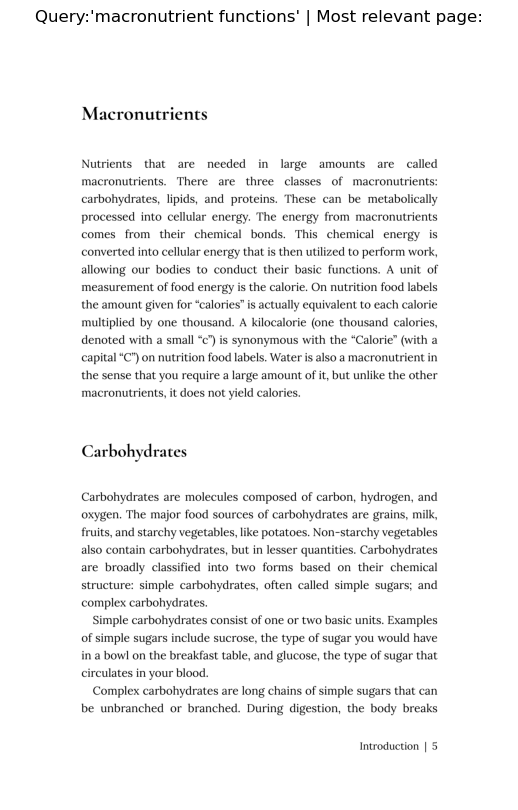

In [43]:
import fitz  #used to extract text from every page from the pdf

#open pdf and load target
pdf_path = "human-nutrition-text.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(5 + 41) #page numbers of our pdf start from 41+

#get the image of the pdf
img = page.get_pixmap(dpi=300)

doc.close()

#convert the pixmap to a numpu array
img_array = np.frombuffer(img.samples_mv, dtype=np.uint8).reshape((img.h, img.w, img.n))

#display the image using matplotlib

import matplotlib.pyplot as plt
plt.figure(figsize=(13,10))
plt.imshow(img_array)
plt.title(f"Query:'{query}' | Most relevant page:")
plt.axis("off")
plt.show()

### Similiarity measures: dot product and cosine similiarity

In [44]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1,vector2)
    
def cosine_similiarity(vector1, vector2):
    dot_product = torch.dot(vector1,vector2)

    #get euclidean/L2 norm
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product/ (norm_vector1 * norm_vector2)

#Example of vector/tensors

vector1= torch.tensor([1,2,3], dtype=torch.float32)
vector2= torch.tensor([1,2,3], dtype=torch.float32)
vector3= torch.tensor([4,5,6], dtype=torch.float32)
vector4= torch.tensor([-1,-2,-3], dtype=torch.float32)

#calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1,vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1,vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1,vector4))

#cosine similiarity
print("Cosine similiarty between vector1 and vector2 :", cosine_similiarity(vector1, vector2))
print("Cosine similiarty between vector1 and vector3 :", cosine_similiarity(vector1, vector3))
print("Cosine similiarty between vector1 and vector4 :", cosine_similiarity(vector1, vector4))

Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similiarty between vector1 and vector2 : tensor(1.0000)
Cosine similiarty between vector1 and vector3 : tensor(0.9746)
Cosine similiarty between vector1 and vector4 : tensor(-1.0000)


### Functionizing our semantic search pipeline

In [45]:
def retrieve_relevant_resources(query:str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    #Embed the query
    query_embedding = model.encode(query,convert_to_tensor=True)

    #Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f" Time taken to get scores on ({len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")
        
    scores,indices = torch.topk(input = dot_scores, k=n_resources_to_return)
    return scores,indices

def print_top_results_and_scores(query: str,
                                 embeddings:torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return )

    #Loop through zipped together  scores and indices from torch.apk
    for score,idx in zip(scores, indices):
        print(f"Score:{score:.4f}")
        print("Text:")
        print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
        print(f"Page number : {pages_and_chunks[idx]['page_number']}")
        print("\n")

In [46]:
query="food high in fiber"
retrieve_relevant_resources(query=query , embeddings=embeddings)
print_top_results_and_scores(query=query, embeddings=embeddings)

 Time taken to get scores on (1680 embeddings: 0.00058 seconds.
 Time taken to get scores on (1680 embeddings: 0.00055 seconds.
Score:0.7015
Text:
The liver uses this glycogen reserve as a way to keep blood-glucose levels
within a narrow range between meal times.When the liver’s glycogen supply is
exhausted, glucose is made from amino acids obtained from the destruction of
proteins in order to maintain metabolic homeostasis. The Functions of
Carbohydrates in the Body | 255
Page number : 255


Score:0.6864
Text:
available source of it, accounting for 70 percent of daily caffeine
consumption.The second readily available source of caffeine is soft drinks,
delivering 16 percent of daily caffeine. (In this case, the bitter caffeine
taste is usually masked by a large amount of added sugar.) Tea is the third
common source of caffeine, at 12 percent. Just how much caffeine is there in a
cup of coffee?It varies.The caffeine content of an average cup of coffee can
range from 102 to 200 milligram

### Loading an LLM locally
We can load an llm locally using Hugging Face transformers

In [ ]:
from huggingface_hub import login

token = "YOUR_HF_TOKEN"

In [48]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


# CPU SETTINGS 

use_quantization_config = False       
attn_implementation = "sdpa"          
model_id = "google/gemma-2b-it"       

print(f"[INFO] Using attention implementation: {attn_implementation}")
print(f"[INFO] Using model_id: {model_id}")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)

# Load model (CPU only)
llm_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=model_id,
    torch_dtype=torch.float32,       
    low_cpu_mem_usage=True,          
    attn_implementation=attn_implementation
)

# Send model to CPU
llm_model.to("cpu")

print("[INFO] Model loaded on CPU successfully.")




[INFO] Using attention implementation: sdpa
[INFO] Using model_id: google/gemma-2b-it


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Model loaded on CPU successfully.


In [49]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): GemmaRMSNorm((2048,), 

In [50]:
def get_model_num_params(model:torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

2506172416

In [51]:
def get_model_mem_size(model):
    mem_params = sum(p.numel() * p.element_size() for p in model.parameters())
    mem_buffers = sum(b.numel() * b.element_size() for b in model.buffers())

    total_bytes = mem_params + mem_buffers

    return {
        "model_mem_bytes": total_bytes,
        "model_mem_mb": round(total_bytes / (1024 ** 2), 2),
        "model_mem_gb": round(total_bytes / (1024 ** 3), 2),
    }

get_model_mem_size(llm_model)


{'model_mem_bytes': 10024690176, 'model_mem_mb': 9560.29, 'model_mem_gb': 9.34}

### Generate our text with LLM

In [52]:
input_text = "What are the macronutrients, and what roles do they play in the human body?"
print(f"Input text:\n{input_text}")


#Create prompt template for instruction tuned model
dialogue_template = [ {"role":"user",
                       "content":input_text}]

#Apply the chat template 
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False,
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
What are the macronutrients, and what roles do they play in the human body?

Prompt (formatted):
<bos><start_of_turn>user
What are the macronutrients, and what roles do they play in the human body?<end_of_turn>
<start_of_turn>model



In [53]:
%%time

#tokenize the input text and send it to the cpu
input_ids = tokenizer(prompt, return_tensors="pt").to("cpu")

#generate outputs from local LLm
outputs = llm_model.generate(**input_ids, max_new_tokens=256)

print(f"Model output(tokens):\n{outputs[0]}\n")

Model output(tokens):
tensor([     2,      2,    106,   1645,    108,   1841,    708,    573, 186809,
        184592, 235269,    578,   1212,  16065,    749,    984,   1554,    575,
           573,   3515,   2971, 235336,    107,    108,    106,   2516,    108,
         21404, 235269,   1517, 235303, 235256,    476,  25497,    576,    573,
        186809, 184592,    578,   1024,  16065,    575,    573,   3515,   2971,
        235292,    109,    688,  12298,   1695, 184592,  66058,    109, 235287,
          5231, 156615,  56227,  66058,    108,    141, 235287,  34428,   4134,
           604,    573,   2971, 235303, 235256,   5999,    578,  29703, 235265,
           108,    141, 235287, 110165,  56227,    708,    573,   7920,   4303,
           576,   4134,    604,   1546,   5999, 235265,    108,    141, 235287,
         25280,  72780,    708,   1941,    674,   1987,   5543,    577,  55997,
        235269,   1582,    685,   3733,  29907, 235269,  16803, 235269,    578,
         19574, 23

In [54]:
#Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<bos><bos><start_of_turn>user
What are the macronutrients, and what roles do they play in the human body?<end_of_turn>
<start_of_turn>model
Sure, here's a breakdown of the macronutrients and their roles in the human body:

**Macronutrients:**

* **Carbohydrates:**
    * Provide energy for the body's cells and tissues.
    * Carbohydrates are the primary source of energy for most cells.
    * Complex carbohydrates are those that take longer to digest, such as whole grains, fruits, and vegetables.
    * Simple carbohydrates are those that are quickly digested, such as sugar, starch, and lactose.

* **Proteins:**
    * Build and repair tissues, enzymes, and hormones.
    * Proteins are essential for immune function, hormone production, and tissue repair.
    * There are different types of proteins, each with specific functions.

* **Fats:**
    * Provide energy, insulation, and help absorb vitamins.
    * Healthy fats include olive oil, avocado, nuts, and seeds.
  

In [55]:
# Nutrition-style questions generated with GPT4
gpt4_questions = [
    "What are the macronutrients, and what roles do they play in the human body?",
    "How do vitamins and minerals differ in their roles and importance for health?",
    "Describe the process of digestion and absorption of nutrients in the human body.",
    "What role does fibre play in digestion? Name five fibre containing foods.",
    "Explain the concept of energy balance and its importance in weight management."
]

# Manually created question list
manual_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the RDI for protein per day?",
    "water soluble vitamins"
]

query_list = gpt4_questions + manual_questions
query_list

['What are the macronutrients, and what roles do they play in the human body?',
 'How do vitamins and minerals differ in their roles and importance for health?',
 'Describe the process of digestion and absorption of nutrients in the human body.',
 'What role does fibre play in digestion? Name five fibre containing foods.',
 'Explain the concept of energy balance and its importance in weight management.',
 'How often should infants be breastfed?',
 'What are symptoms of pellagra?',
 'How does saliva help with digestion?',
 'What is the RDI for protein per day?',
 'water soluble vitamins']

In [56]:
import random

query = random.choice(query_list)
print(f"Query:{query}")

#Get just the scores and indices of top related results
scores,indices = retrieve_relevant_resources(query=query, embeddings=embeddings)
scores,indices

Query:water soluble vitamins
 Time taken to get scores on (1680 embeddings: 0.01544 seconds.


(tensor([0.7893, 0.7625, 0.7386, 0.7099, 0.6996]),
 tensor([855, 801, 756, 755, 848]))

###Augmenting our prompt with context items

Let's create a function to format a prompt with context items

In [57]:
pages_and_chunks[420]

{'page_number': 257,
 'sentence_chunk': 'Image by Forluvoft / Public Domain Sparing Protein In a situation where there is not enough glucose to meet the body’s needs, glucose is synthesized from amino acids.Because there is no storage molecule of amino acids, this process requires the destruction of proteins, primarily from muscle tissue.The presence of adequate glucose basically spares the breakdown of proteins from being used to make glucose needed by the body. Lipid Metabolism As blood-glucose levels rise, the use of lipids as an energy source is The Functions of Carbohydrates in the Body | 257',
 'chunk_char_count': 563,
 'chunk_word_count': 91,
 'chunk_token_count': 140.75}

In [58]:
def prompt_formatter(query: str, 
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

   
    base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.
\nExample 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for blood clotting and bone metabolism.
\nExample 2:
Query: What are the causes of type 2 diabetes?
Answer: Type 2 diabetes is often associated with overnutrition, particularly the overconsumption of calories leading to obesity. Factors include a diet high in refined sugars and saturated fats, which can lead to insulin resistance, a condition where the body's cells do not respond effectively to insulin. Over time, the pancreas cannot produce enough insulin to manage blood sugar levels, resulting in type 2 diabetes. Additionally, excessive caloric intake without sufficient physical activity exacerbates the risk by promoting weight gain and fat accumulation, particularly around the abdomen, further contributing to insulin resistance.
\nExample 3:
Query: What is the importance of hydration for physical performance?
Answer: Hydration is crucial for physical performance because water plays key roles in maintaining blood volume, regulating body temperature, and ensuring the transport of nutrients and oxygen to cells. Adequate hydration is essential for optimal muscle function, endurance, and recovery. Dehydration can lead to decreased performance, fatigue, and increased risk of heat-related illnesses, such as heat stroke. Drinking sufficient water before, during, and after exercise helps ensure peak physical performance and recovery.
\nNow use the following context items to answer the user query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    # Update base prompt with context items and query   
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

In [59]:
input_ids = tokenizer(prompt, return_tensors="pt").to("cpu")

#Generate an output of tokens
outputs = llm_model.generate(**input_ids, temperature=0.7, do_sample =True, max_new_tokens=256)

#Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])
print(f"Query:{query}")
print(f"RAG answer:\m{output_text.replace(prompt,'')}")

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Mohanty Sameer\AppData\Local\Temp\ipykernel_4836\2497509726.py:9: SyntaxWarning: invalid escape sequence '\m'
  print(f"RAG answer:\m{output_text.replace(prompt,'')}")


Query:water soluble vitamins
RAG answer:\m<bos>Sure, here's a breakdown of the macronutrients and their roles in the human body:

**Macronutrients** are nutrients that the body needs in large amounts to maintain good health. They provide the building blocks for tissues, organs, and enzymes in the body. 

**Three main macronutrients are:**

**Carbohydrates:**

* Provide the body with energy for cells and tissues.
* Complex carbohydrates like starches, fiber, and oats contribute to satiety and help regulate blood sugar levels.
* Examples include bread, pasta, rice, potatoes, and fruits.

**Proteins:**

* Build and repair tissues, hormones, and enzymes.
* Essential for muscle growth and recovery, immune function, and making antibodies.
* Examples include meat, fish, poultry, eggs, dairy products, nuts, and legumes.

**Fats:**

* Provide energy, insulation, and help absorb fat-soluble vitamins.
* Essential for hormone production, skin, and cell function.
* Examples include olive oil, nuts,

### Functionize our LLM answering feature

In [68]:
def ask(query:str,
        temperature: float=0.7,
        max_new_tokens: int=256,
        format_answer_text = True,
        return_answer_only = True):

    #Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query, embeddings, n_resources_to_return=10)

    #Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    #Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu()

    #Create the prompt and format it with context items
    prompt = prompt_formatter(query=query, context_items=context_items)

    #Tokenize the prompt
    input_ids = tokenizer(prompt, return_tensors="pt").to("cpu")

    #Generate an output of tokens
    outputs = llm_model.generate(**input_ids, temperature=temperature, do_sample=True,max_new_tokens = max_new_tokens)

    #Decode the tokens into text
    output_text=tokenizer.decode(outputs[0])

    #Format the answer
    if format_answer_text:
        output_text = output_text.replace(prompt,"").replace("<bos>","").replace("<eos>","")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text
    
    return output_text, context_items

In [72]:
query=random.choice(query_list)
print(f"Query:{query}")
ask(query=query,temperature=0.2, return_answer_only=False)

Query:How do vitamins and minerals differ in their roles and importance for health?
 Time taken to get scores on (1680 embeddings: 0.01476 seconds.


("Sure, here's the answer to the user's query:\n\n**Vitamins** are required by the body in lesser amounts but are still essential for carrying out bodily functions. Vitamins assist in the process as cofactors or components of enzymes. They play many essential roles in the body, including making red blood cells, synthesizing bone tissue, and playing a role in normal vision, nervous system function, and immune system function.\n\n**Minerals** are required by the body in hundreds of milligrams. They are essential for enzyme function, maintaining fluid balance, building bone tissue, and protecting against harmful free radicals in the body.",
 [{'page_number': 9,
   'sentence_chunk': 'Minerals Major Functions Macro Sodium Fluid balance, nerve transmission, muscle contraction Chloride Fluid balance, stomach acid production Potassium Fluid balance, nerve transmission, muscle contraction Calcium Bone and teeth health maintenance, nerve transmission, muscle contraction, blood clotting Phosphoru